Số ảnh sau augment: 11


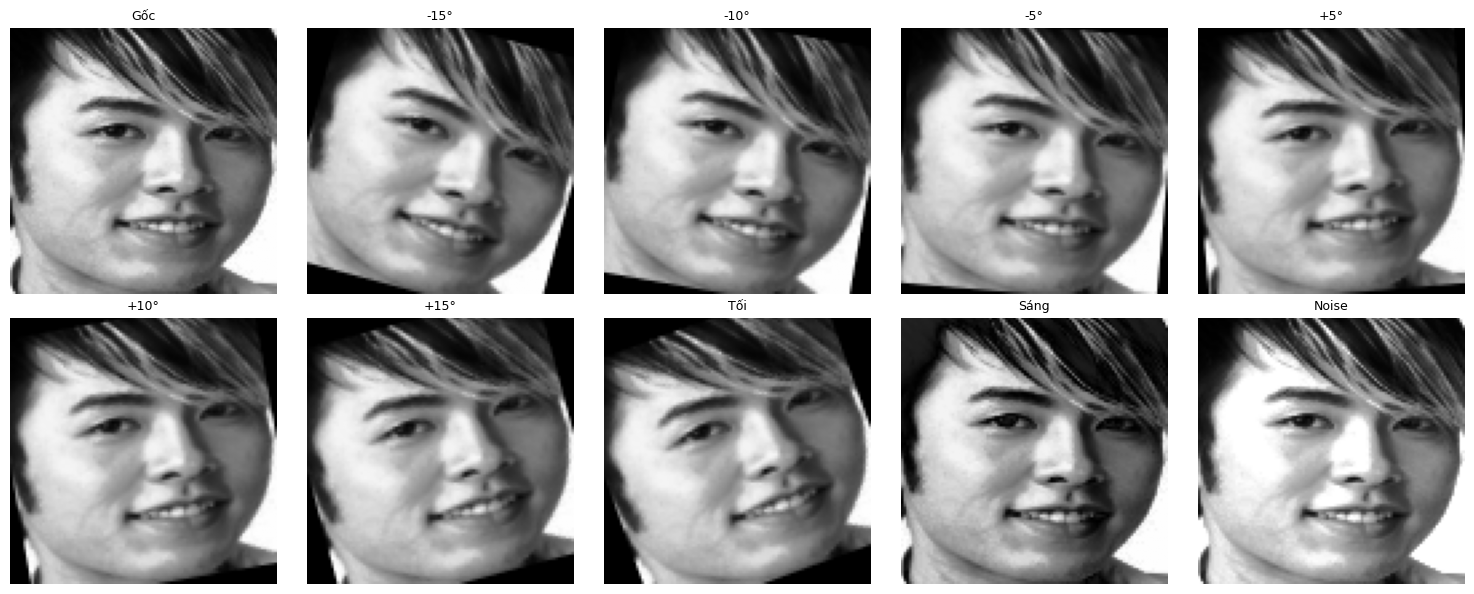

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def augment(img):
    """
    Input:  ảnh grayscale 100x100
    Output: list các ảnh đã augment
    """
    results = [img]  # giữ ảnh gốc

    # 1. Rotate nhẹ
    h, w = img.shape
    center = (w // 2, h // 2)
    for angle in [-20,-15, -10, -5, 5, 10, 15, 20]:
        M = cv2.getRotationMatrix2D(center, angle, 1.0)
        rotated = cv2.warpAffine(img, M, (w, h))
        results.append(rotated)

    # 2. Brightness
    for beta in [-30, 30]:
        bright = cv2.convertScaleAbs(img, alpha=1.0, beta=beta)
        results.append(bright)

    # 3. Gaussian noise
    noise = np.random.normal(0, 10, img.shape).astype(np.float32)
    noisy = np.clip(img.astype(np.float32) + noise, 0, 255).astype(np.uint8)
    results.append(noisy)

    return results  


# ── Test với 1 ảnh ──────────────────────────────────────────
path = r".\datasource\Ca sĩ\ca sĩ Akira Phan\1671998435972282000.jpg"

raw = np.fromfile(path, dtype=np.uint8)
img = cv2.imdecode(raw, cv2.IMREAD_GRAYSCALE)

if img is None:
    print("Load failed!")
else:
    img = cv2.resize(img, (100, 100))
img = cv2.equalizeHist(img)

augmented = augment(img)
print(f"Số ảnh sau augment: {len(augmented)}")

# Visualize
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
titles = ["Gốc",
          "-15°", "-10°", "-5°", "+5°", "+10°", "+15°",
          "Tối", "Sáng", "Noise"]
for i, (ax, title) in enumerate(zip(axes.ravel(), titles)):
    ax.imshow(augmented[i], cmap="gray")
    ax.set_title(title, fontsize=9)
    ax.axis("off")

plt.tight_layout()
plt.savefig("augment_preview.png")
plt.show()